# **01. Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **02. Load Dataset**

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Datasets/ROSIDS23.csv"
df = pd.read_csv(DATASET_PATH)

# **03. Dataset Overview**

In [ ]:
df.shape

(136681, 84)

In [ ]:
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.3.4-192.168.3.6-11311-60792-6,192.168.3.6,60792,192.168.3.4,11311,6,07/07/2023 02:10:23 PM,6260,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,192.168.3.4-192.168.3.6-11311-60794-6,192.168.3.6,60794,192.168.3.4,11311,6,07/07/2023 02:10:23 PM,5903,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,192.168.3.4-192.168.3.6-11311-39922-6,192.168.3.6,39922,192.168.3.4,11311,6,07/07/2023 02:10:32 PM,4523,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,192.168.3.4-192.168.3.6-11311-55266-6,192.168.3.6,55266,192.168.3.4,11311,6,07/07/2023 02:11:11 PM,5191,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,192.168.3.6-192.168.3.7-43770-11111-6,192.168.3.7,11111,192.168.3.6,43770,6,07/07/2023 02:10:03 PM,72625778,2200,2212,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [ ]:
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

In [ ]:
df.dtypes

,0
Flow ID,object
Src IP,object
Src Port,int64
Dst IP,object
Dst Port,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,float64
Idle Min,float64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Flow ID,0
Src IP,0
Src Port,0
Dst IP,0
Dst Port,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [ ]:
df["Label"].value_counts()

,count
Label,
Benign,62511
DoS,31000
Subflood,30064
UnauthPub,7817
UnauthSub,5289


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Src Port,136681.0,3.539043e+04,1.756249e+04,0.0,11311.0,38984.0,49178.0,6.553500e+04
Dst Port,136681.0,2.792530e+04,2.060046e+04,0.0,11311.0,35222.0,44930.0,6.541800e+04
Protocol,136681.0,6.065203e+00,9.652164e-01,0.0,6.0,6.0,6.0,1.700000e+01
Flow Duration,136681.0,3.093967e+07,3.490355e+07,0.0,4123.0,508341.0,58780722.0,1.200000e+08
Tot Fwd Pkts,136681.0,5.930385e+02,5.018832e+03,0.0,1.0,5.0,33.0,1.192570e+05
...,...,...,...,...,...,...,...,...
Active Min,136681.0,2.777034e+06,8.853524e+06,0.0,0.0,0.0,268.0,1.129778e+08
Idle Mean,136681.0,6.463119e+06,1.596497e+07,0.0,0.0,0.0,5525405.0,1.196444e+08
Idle Std,136681.0,1.126476e+06,4.999828e+06,0.0,0.0,0.0,0.0,4.755196e+07
Idle Max,136681.0,7.469949e+06,1.776872e+07,0.0,0.0,0.0,5744825.0,1.196444e+08


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136681 entries, 0 to 136680
Data columns (total 84 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow ID            136681 non-null  object 
 1   Src IP             136681 non-null  object 
 2   Src Port           136681 non-null  int64  
 3   Dst IP             136681 non-null  object 
 4   Dst Port           136681 non-null  int64  
 5   Protocol           136681 non-null  int64  
 6   Timestamp          136681 non-null  object 
 7   Flow Duration      136681 non-null  int64  
 8   Tot Fwd Pkts       136681 non-null  int64  
 9   Tot Bwd Pkts       136681 non-null  int64  
 10  TotLen Fwd Pkts    136681 non-null  float64
 11  TotLen Bwd Pkts    136681 non-null  float64
 12  Fwd Pkt Len Max    136681 non-null  float64
 13  Fwd Pkt Len Min    136681 non-null  float64
 14  Fwd Pkt Len Mean   136681 non-null  float64
 15  Fwd Pkt Len Std    136681 non-null  float64
 16  Bw

# **04. Exploratory Data Analysis**

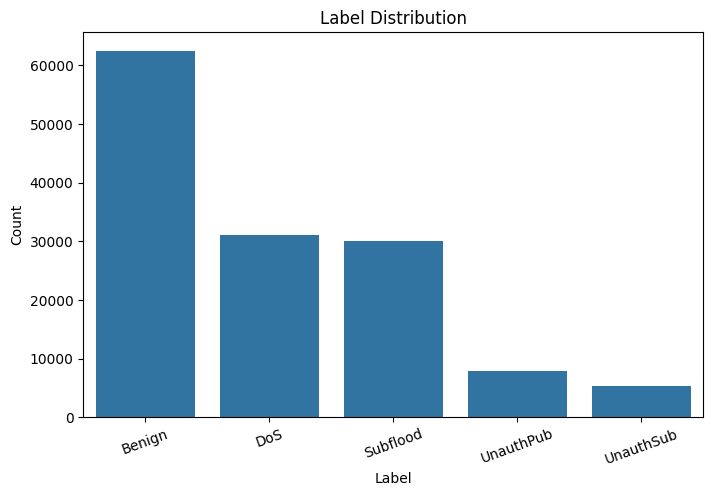

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Label", order=df["Label"].value_counts().index)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [ ]:
df["Label"].value_counts(normalize=True).mul(100).round(2)

,proportion
Label,
Benign,45.73
DoS,22.68
Subflood,22.00
UnauthPub,5.72
UnauthSub,3.87


## ***Object/categorical columns***

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
  print(f"\n{col}")
  print("Unique Values: ", df[col].nunique())
  print(df[col].head(3))


Flow ID
Unique Values:  71793
0    192.168.3.4-192.168.3.6-11311-60792-6
1    192.168.3.4-192.168.3.6-11311-60794-6
2    192.168.3.4-192.168.3.6-11311-39922-6
Name: Flow ID, dtype: object

Src IP
Unique Values:  6
0    192.168.3.6
1    192.168.3.6
2    192.168.3.6
Name: Src IP, dtype: object

Dst IP
Unique Values:  9
0    192.168.3.4
1    192.168.3.4
2    192.168.3.4
Name: Dst IP, dtype: object

Timestamp
Unique Values:  13625
0    07/07/2023 02:10:23 PM
1    07/07/2023 02:10:23 PM
2    07/07/2023 02:10:32 PM
Name: Timestamp, dtype: object

Label
Unique Values:  5
0    Benign
1    Benign
2    Benign
Name: Label, dtype: object
